In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import librosa
import librosa.display

In [11]:
# x, sampling_rate = librosa.load('C:/Users/LShel/OneDrive/Documents/Applied_Machine_Learning/Datasets/Data_2/E minor/873455 Solu Music - Fade feat. KimBlee (Original Mix (Part I)).mp3', sr=None)
x, sampling_rate = librosa.load('../Data/processed/E minor/873455 Solu Music - Fade feat. KimBlee (Original Mix (Part I)).mp3')

[Text(0.5, 1.0, 'Chromagram from Harmonic Component')]

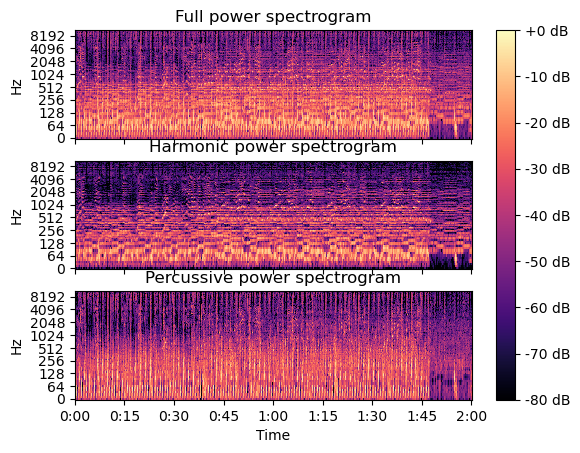

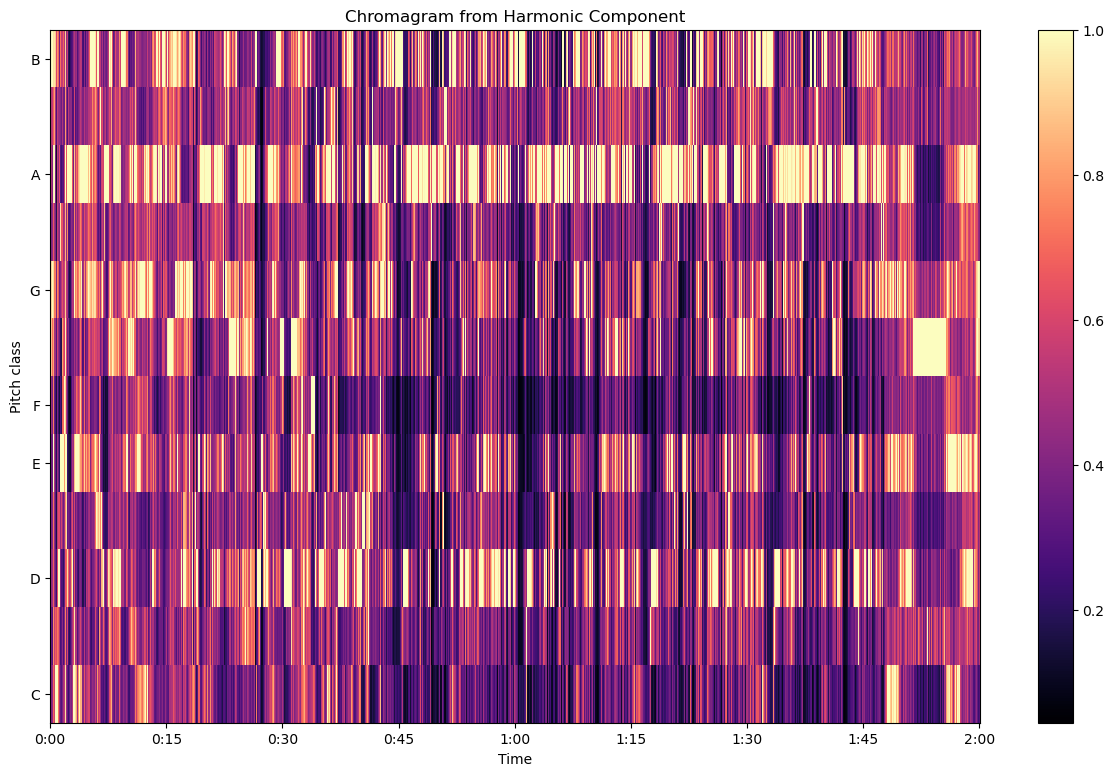

In [12]:
S = librosa.stft(x)
H, P = librosa.decompose.hpss(S)

fig, ax = plt.subplots(nrows=3, sharex=True, sharey=True)
img = librosa.display.specshow(librosa.amplitude_to_db(np.abs(S), ref=np.max),
                               y_axis='log', x_axis='time', ax=ax[0])
ax[0].set(title='Full power spectrogram')
ax[0].label_outer()

librosa.display.specshow(librosa.amplitude_to_db(np.abs(H), ref=np.max(np.abs(S))),
                         y_axis='log', x_axis='time', ax=ax[1])
ax[1].set(title='Harmonic power spectrogram')
ax[1].label_outer()

librosa.display.specshow(librosa.amplitude_to_db(np.abs(P), ref=np.max(np.abs(S))),
                         y_axis='log', x_axis='time', ax=ax[2])
ax[2].set(title='Percussive power spectrogram')

fig.colorbar(img, ax=ax, format='%+2.0f dB')

chroma = librosa.feature.chroma_stft(S=np.abs(H), sr=sampling_rate)

fig, ax = plt.subplots(figsize=(15, 9))
img = librosa.display.specshow(chroma, y_axis='chroma', x_axis='time', ax=ax)
fig.colorbar(img, ax=ax)
ax.set(title='Chromagram from Harmonic Component')